# Heart Attack Risk Modeling

1. Logistic Regression
2. ANN (MLPClassifier)
3. KNN
4. Decision Tree (CART)
5. Random Forest
6. AdaBoost (Boosting)
7. Gradient Boosting (Boosting)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, balanced_accuracy_score, classification_report,
    confusion_matrix, roc_curve
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
print('Libraries imported successfully.')

Libraries imported successfully.


## Load and Inspect Data


In [2]:
DATA_PATH = 'heart_attack_youngsters_india.csv'
df_raw = pd.read_csv(DATA_PATH)

print('Shape:', df_raw.shape)
print('\nColumns:')
print(df_raw.columns.tolist())
print('\nTarget distribution (raw):')
print(df_raw['Heart Attack Likelihood'].value_counts(dropna=False))

display(df_raw.head())

Shape: (10000, 26)

Columns:
['Age', 'Gender', 'Region', 'Urban/Rural', 'SES', 'Smoking Status', 'Alcohol Consumption', 'Diet Type', 'Physical Activity Level', 'Screen Time (hrs/day)', 'Sleep Duration (hrs/day)', 'Family History of Heart Disease', 'Diabetes', 'Hypertension', 'Cholesterol Levels (mg/dL)', 'BMI (kg/m²)', 'Stress Level', 'Blood Pressure (systolic/diastolic mmHg)', 'Resting Heart Rate (bpm)', 'ECG Results', 'Chest Pain Type', 'Maximum Heart Rate Achieved', 'Exercise Induced Angina', 'Blood Oxygen Levels (SpO2%)', 'Triglyceride Levels (mg/dL)', 'Heart Attack Likelihood']

Target distribution (raw):
Heart Attack Likelihood
No     7962
Yes    2038
Name: count, dtype: int64


,Age,Gender,Region,Urban/Rural,SES,Smoking Status,Alcohol Consumption,Diet Type,Physical Activity Level,Screen Time (hrs/day),...,Stress Level,Blood Pressure (systolic/diastolic mmHg),Resting Heart Rate (bpm),ECG Results,Chest Pain Type,Maximum Heart Rate Achieved,Exercise Induced Angina,Blood Oxygen Levels (SpO2%),Triglyceride Levels (mg/dL),Heart Attack Likelihood
0,30,Male,East,Urban,Middle,Never,Regularly,Non-Vegetarian,Sedentary,3,...,High,177.0/63.1,82,Normal,Non-anginal,183,No,94.1,58,No
1,24,Female,East,Urban,Low,Occasionally,Occasionally,Non-Vegetarian,Sedentary,15,...,High,137.5/110.7,76,Normal,Non-anginal,118,No,97.1,341,No
2,24,Female,North,Urban,Low,Occasionally,Occasionally,Vegan,High,15,...,Low,138.3/76.6,86,Normal,Typical,164,No,92.7,373,Yes
3,27,Male,East,Urban,Middle,Occasionally,Never,Vegetarian,Sedentary,6,...,Medium,177.1/90.0,106,Normal,Non-anginal,188,No,98.4,102,Yes
4,21,Female,West,Rural,Low,Occasionally,Occasionally,Vegetarian,Moderate,4,...,Low,130.7/108.8,73,Normal,Atypical,216,No,94.9,235,No


## Preprocessing Design

Raw data has mixed types and one compound blood pressure field (`systolic/diastolic`) that must be split for machine learning.

1. Create a safe copy of data
2. Split blood pressure text into numeric `Systolic_BP` and `Diastolic_BP`
3. Standardize target labels (`Yes`/`No` -> `1`/`0`)
4. Build train/test split with stratification
5. Build two preprocessing pipelines:
   - Scaled numeric + one-hot categorical (for LR, ANN, KNN)
   - Unscaled numeric + one-hot categorical (for tree and boosting models)
6. Add SMOTE resampling inside each model-training pipeline

Use sklearn `ColumnTransformer` + `Pipeline` for preprocessing, then use an imbalanced-learn pipeline so SMOTE is applied only on training folds (prevents data leakage).


In [3]:
# Work on a copy
df = df_raw.copy()

# Split blood pressure text column into two numeric columns
bp_col = 'Blood Pressure (systolic/diastolic mmHg)'
if bp_col in df.columns:
    bp_split = df[bp_col].astype(str).str.split('/', n=1, expand=True)
    df['Systolic_BP'] = pd.to_numeric(bp_split[0], errors='coerce')
    df['Diastolic_BP'] = pd.to_numeric(bp_split[1], errors='coerce')
    df = df.drop(columns=[bp_col])

# Optional rename for easier typing
if 'BMI (kg/m²)' in df.columns:
    df = df.rename(columns={'BMI (kg/m²)': 'BMI'})

target_col = 'Heart Attack Likelihood'

y = (
    df[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'yes': 1, 'no': 0})
)

if y.isna().any():
    bad_values = df.loc[y.isna(), target_col].unique()
    raise ValueError(f'Unexpected target values found: {bad_values}')

X = df.drop(columns=[target_col])

# Train-test split with stratify to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print('Training shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('\nTrain target distribution:')
print(y_train.value_counts(normalize=True).rename('ratio'))
print('\nNumeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

# Build OneHotEncoder compatible with different sklearn versions(covert categorical data to numbers)
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_scaled_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_unscaled_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe)
])

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', numeric_scaled_pipe, numeric_features),
        ('cat', categorical_pipe, categorical_features)
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('num', numeric_unscaled_pipe, numeric_features),
        ('cat', categorical_pipe, categorical_features)
    ]
)

print('Preprocessing pipelines are ready.')

Training shape: (8000, 26)
Test shape: (2000, 26)

Train target distribution:
Heart Attack Likelihood
0    0.79625
1    0.20375
Name: ratio, dtype: float64

Numeric features: 11
Categorical features: 15
Preprocessing pipelines are ready.


## Model Definition

- **Logistic Regression**: linear baseline, interpretable, strong for tabular classification
- **ANN (MLP)**: learns non-linear feature interactions
- **KNN**: distance-based local pattern learner
- **Decision Tree (CART)**: human-readable rule-based model
- **Random Forest**: ensemble of trees, robust and usually strong on tabular data
- **AdaBoost**: boosting that sequentially focuses on hard errors
- **Gradient Boosting**: additive boosting with gradient optimization

Created sklearn pipelines per model so preprocessing is automatically and correctly applied.


In [4]:
#creates a pipeline for models
def make_model_pipeline(model, use_scaled_preprocessing=True, use_smote=True):
    preprocessor = preprocessor_scaled if use_scaled_preprocessing else preprocessor_unscaled
    steps = [('preprocessor', preprocessor)]
#add SMOTE
    if use_smote:
        steps.append((
            'sampler',
            SMOTE(sampling_strategy=0.75, k_neighbors=5, random_state=RANDOM_STATE)
        ))

    steps.append(('model', model))
    return ImbPipeline(steps=steps)

model_pipelines = {
    'Logistic Regression': make_model_pipeline(
        LogisticRegression(max_iter=2500, class_weight='balanced', random_state=RANDOM_STATE),
        use_scaled_preprocessing=True,
        use_smote=True
    ),
    'ANN (MLP)': make_model_pipeline(
        MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
            random_state=RANDOM_STATE
        ),
        use_scaled_preprocessing=True,
        use_smote=True
    ),
    'KNN': make_model_pipeline(
        KNeighborsClassifier(n_neighbors=11, weights='distance', metric='minkowski', p=2),
        use_scaled_preprocessing=True,
        use_smote=True
    ),
    'Decision Tree (CART)': make_model_pipeline(
        DecisionTreeClassifier(
            criterion='gini',
            max_depth=8,
            min_samples_leaf=10,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ),
        use_scaled_preprocessing=False,
        use_smote=True
    ),
    'Random Forest': make_model_pipeline(
        RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        use_scaled_preprocessing=False,
        use_smote=True
    ),
    'AdaBoost': make_model_pipeline(
        AdaBoostClassifier(
            n_estimators=300,
            learning_rate=0.05,
            random_state=RANDOM_STATE
        ),
        use_scaled_preprocessing=False,
        use_smote=True
    ),
    'Gradient Boosting': make_model_pipeline(
        GradientBoostingClassifier(
            learning_rate=0.05,
            n_estimators=300,
            max_depth=3,
            subsample=0.9,
            random_state=RANDOM_STATE
        ),
        use_scaled_preprocessing=False,
        use_smote=True
    )
}

print(f'Models configured: {len(model_pipelines)}')
print('SMOTE resampling is enabled inside all training pipelines.')
for m in model_pipelines.keys():
    print('-', m)

Models configured: 7
SMOTE resampling is enabled inside all training pipelines.
- Logistic Regression
- ANN (MLP)
- KNN
- Decision Tree (CART)
- Random Forest
- AdaBoost
- Gradient Boosting


## Cross-Validate, and Evaluate

A single train/test score can be noisy. Cross-validation gives stability; test metrics reflect final generalization.

For each model:

1. 5-fold stratified CV on training set (AUC)
2. Fit on full training set
3. Evaluate on untouched test set

Use consistent metrics across all models: Accuracy, Balanced Accuracy, Precision, Recall, F1, and AUC.
SMOTE is embedded in each model pipeline, so resampling happens only on training folds and never on validation/test data.


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
#storage variables
results = []          #final test metrics
cv_summary = []       #cross-validation scores
trained_models = {}   #saved trained models
pred_store = {}       #predictions
#Loop
for model_name, pipe in model_pipelines.items():
    print(f'Running: {model_name}')

    # Cross-validation on training split only
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_summary.append({
        'Model': model_name,
        'CV AUC Mean': cv_scores.mean(),
        'CV AUC Std': cv_scores.std()
    })

    # Fit on full train split(train on full data)
    pipe.fit(X_train, y_train)
    trained_models[model_name] = pipe

    # Test predictions
    y_pred = pipe.predict(X_test)

    if hasattr(pipe, 'predict_proba'):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    elif hasattr(pipe, 'decision_function'):
        raw = pipe.decision_function(X_test)
        y_prob = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    else:
        y_prob = y_pred.astype(float)

    pred_store[model_name] = {
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index('Model').sort_values(
    by=['Recall', 'AUC', 'F1-Score'], ascending=False
)

cv_df = pd.DataFrame(cv_summary).set_index('Model').sort_values(by='CV AUC Mean', ascending=False)

print('\nCross-validation summary (training split):')
display(cv_df.round(4))

print('Test-set comparison (sorted by Recall, AUC, F1):')
display(results_df.round(4))

Running: Logistic Regression
Running: ANN (MLP)
Running: KNN
Running: Decision Tree (CART)
Running: Random Forest
Running: AdaBoost
Running: Gradient Boosting

Cross-validation summary (training split):


,CV AUC Mean,CV AUC Std
Model,,
Gradient Boosting,0.5092,0.0183
Decision Tree (CART),0.5036,0.0150
AdaBoost,0.5020,0.0190
ANN (MLP),0.4994,0.0144
Random Forest,0.4979,0.0225
Logistic Regression,0.4947,0.0191
KNN,0.4918,0.0153


Test-set comparison (sorted by Recall, AUC, F1):


,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,AUC
Model,,,,,,
KNN,0.4210,0.5133,0.2106,0.6691,0.3204,0.5114
Logistic Regression,0.5075,0.4920,0.1985,0.4657,0.2784,0.5052
ANN (MLP),0.6635,0.5034,0.2088,0.2328,0.2202,0.5095
Decision Tree (CART),0.7720,0.5022,0.2209,0.0466,0.0769,0.4948
AdaBoost,0.7960,0.5000,0.0000,0.0000,0.0000,0.5157
Gradient Boosting,0.7955,0.4997,0.0000,0.0000,0.0000,0.5155
Random Forest,0.7960,0.5000,0.0000,0.0000,0.0000,0.5154


## Visual Comparison

1. Bar chart of key metrics
2. Confusion matrices for every model
3. ROC curve comparison


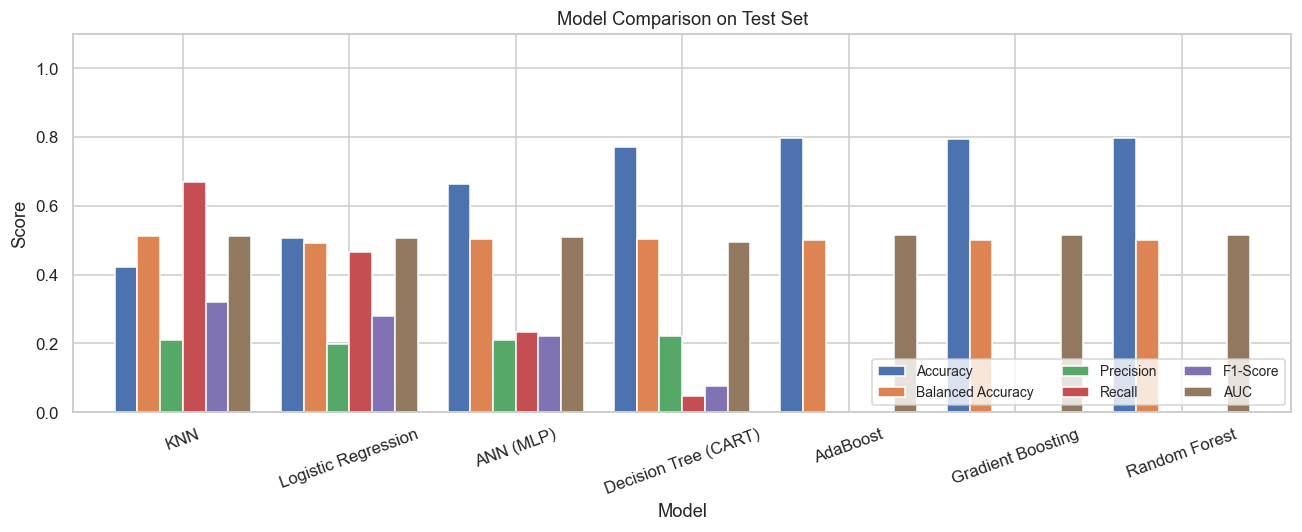

In [6]:
# 1) Bar chart for core metrics
metric_cols = ['Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
plot_df = results_df[metric_cols].copy()

ax = plot_df.plot(kind='bar', figsize=(12, 5), width=0.82, edgecolor='white')
ax.set_title('Model Comparison on Test Set')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='lower right', ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

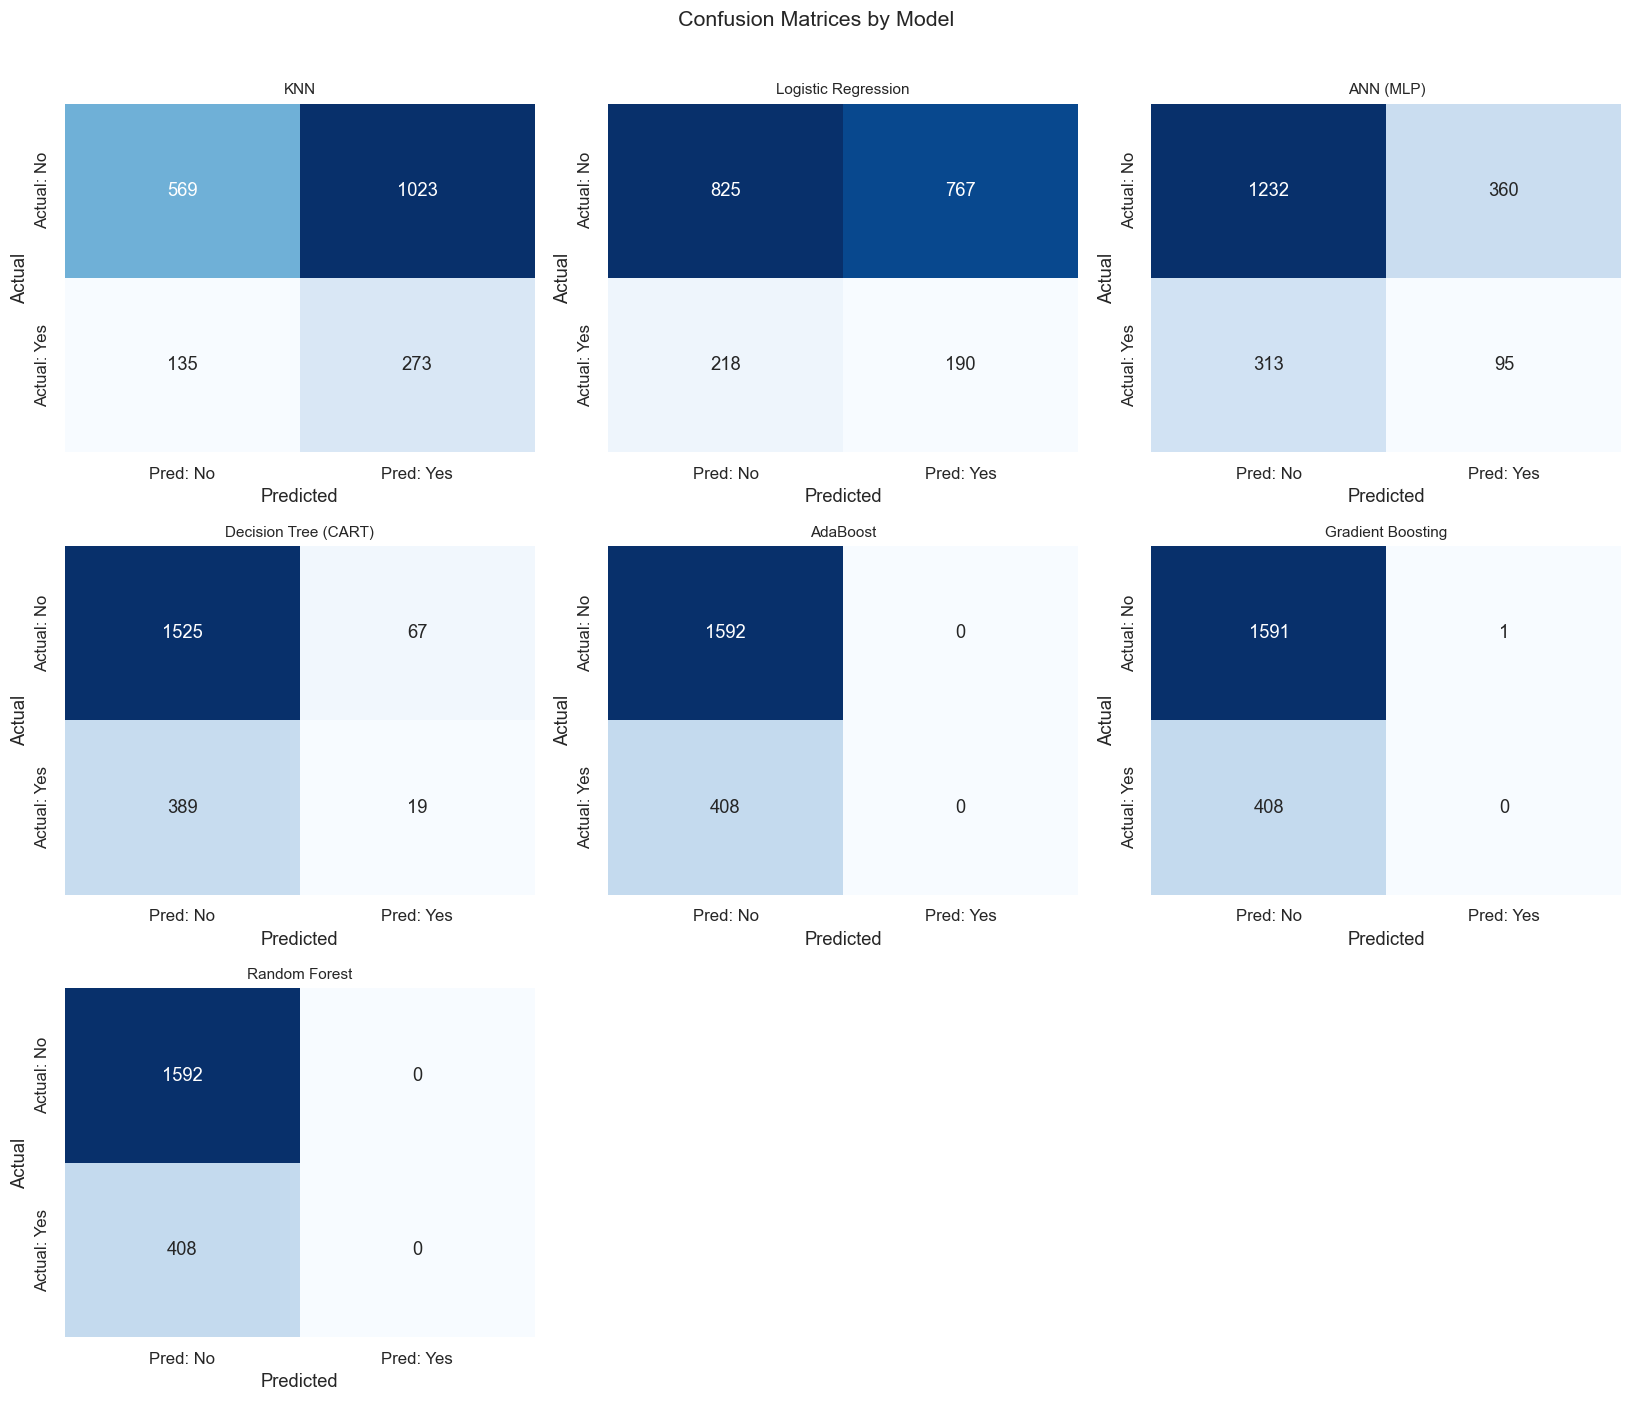

In [7]:
# 2) Confusion matrices
import math

model_names = list(results_df.index)
n_models = len(model_names)
n_cols = 3
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for i, model_name in enumerate(model_names):
    ax = axes[i]
    cm = confusion_matrix(y_test, pred_store[model_name]['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', cbar=False,
        xticklabels=['Pred: No', 'Pred: Yes'],
        yticklabels=['Actual: No', 'Actual: Yes'],
        ax=ax
    )
    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Confusion Matrices by Model', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

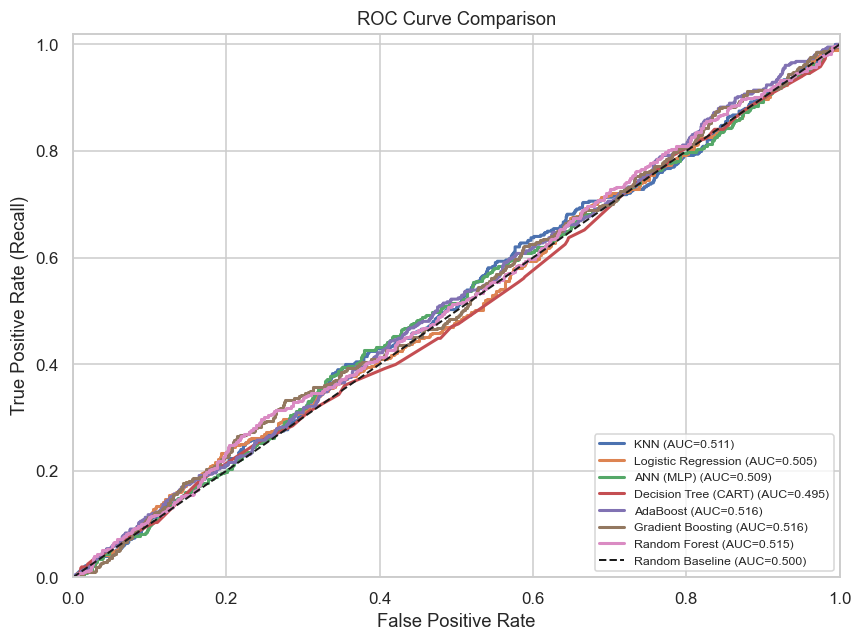

In [8]:
# 3) ROC curves
plt.figure(figsize=(8, 6))

for model_name in model_names:
    y_prob = pred_store[model_name]['y_prob']
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.3, label='Random Baseline (AUC=0.500)')
plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

## Classification Reports

importanat should detect positive risk cases

1. KNN recall for Yes is about 0.67
2. Logistic Regression recall for Yes is about 0.47
3. Others are very low or near zero recall for Yes

Precision and Recall per class show where each model fails or succeeds in detail.


In [9]:
for model_name in model_names:
    print('=' * 70)
    print(model_name)
    print('=' * 70)
    print(classification_report(
        y_test,
        pred_store[model_name]['y_pred'],
        target_names=['No (0)', 'Yes (1)'],
        zero_division=0
    ))

KNN
              precision    recall  f1-score   support

      No (0)       0.81      0.36      0.50      1592
     Yes (1)       0.21      0.67      0.32       408

    accuracy                           0.42      2000
   macro avg       0.51      0.51      0.41      2000
weighted avg       0.69      0.42      0.46      2000

Logistic Regression
              precision    recall  f1-score   support

      No (0)       0.79      0.52      0.63      1592
     Yes (1)       0.20      0.47      0.28       408

    accuracy                           0.51      2000
   macro avg       0.49      0.49      0.45      2000
weighted avg       0.67      0.51      0.56      2000

ANN (MLP)
              precision    recall  f1-score   support

      No (0)       0.80      0.77      0.79      1592
     Yes (1)       0.21      0.23      0.22       408

    accuracy                           0.66      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.68      0.66      0

## Tree-Based Interpretability

Extract feature importance from Random Forest and show top contributors.

Use fitted preprocessing feature names and align them with model importances.


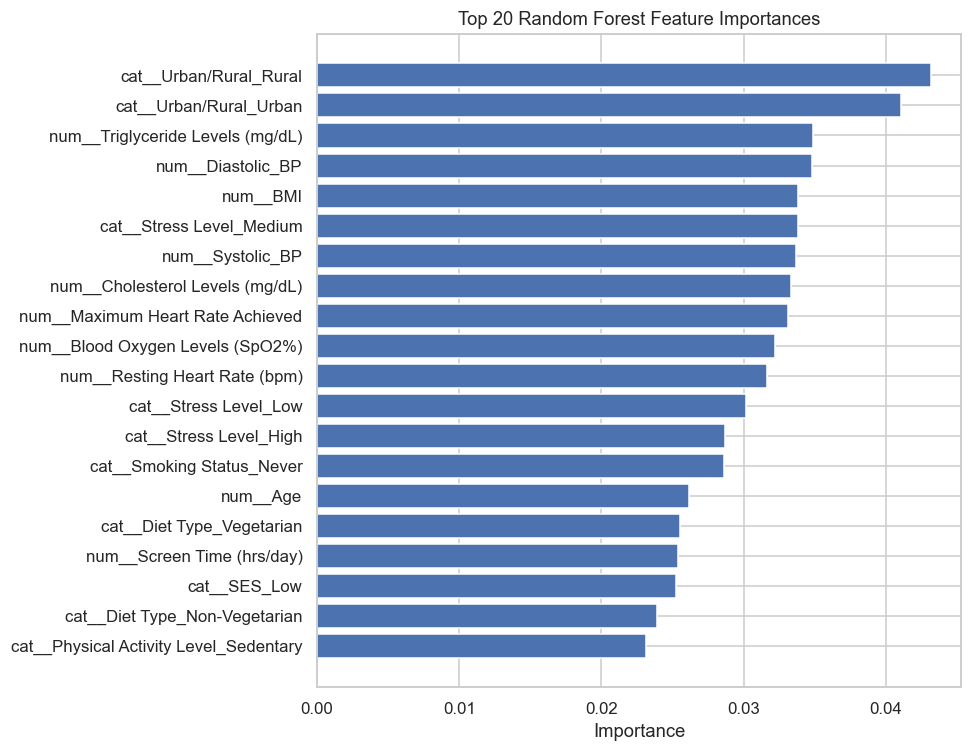

,Feature,Importance
20,cat__Urban/Rural_Rural,0.043164
21,cat__Urban/Rural_Urban,0.041056
8,num__Triglyceride Levels (mg/dL),0.034866
10,num__Diastolic_BP,0.034842
4,num__BMI,0.033840
45,cat__Stress Level_Medium,0.033821
9,num__Systolic_BP,0.033712
3,num__Cholesterol Levels (mg/dL),0.033304
6,num__Maximum Heart Rate Achieved,0.033141
7,num__Blood Oxygen Levels (SpO2%),0.032216


In [10]:
rf_pipe = trained_models.get('Random Forest')

if rf_pipe is None:
    print('Random Forest model not found.')
else:
    rf_model = rf_pipe.named_steps['model']
    rf_preprocessor = rf_pipe.named_steps['preprocessor']
#Random Forest automatically calculates how important each feature is for prediction
    feature_names = rf_preprocessor.get_feature_names_out()
    importances = rf_model.feature_importances_

    imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    top_n = 20
    top_imp = imp_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(9, 7))
    plt.barh(top_imp['Feature'], top_imp['Importance'])
    plt.title(f'Top {top_n} Random Forest Feature Importances')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

    display(imp_df.head(20))

## Final Decision Logic

In medical-risk screening, missing a true positive (false negative) can be costly. So **Recall** is often prioritized.

Create a ranking table prioritizing:

1. Recall
2. AUC(Area under the curve)
3. F1-Score


In [11]:
ranking = results_df.sort_values(by=['Recall', 'AUC', 'F1-Score'], ascending=False).copy()
best_model_name = ranking.index[0]

print('Ranking Priority: Recall -> AUC -> F1-Score')
display(ranking.round(4))

print(f'Recommended model under this criterion: {best_model_name}')

Ranking Priority: Recall -> AUC -> F1-Score


,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,AUC
Model,,,,,,
KNN,0.4210,0.5133,0.2106,0.6691,0.3204,0.5114
Logistic Regression,0.5075,0.4920,0.1985,0.4657,0.2784,0.5052
ANN (MLP),0.6635,0.5034,0.2088,0.2328,0.2202,0.5095
Decision Tree (CART),0.7720,0.5022,0.2209,0.0466,0.0769,0.4948
AdaBoost,0.7960,0.5000,0.0000,0.0000,0.0000,0.5157
Gradient Boosting,0.7955,0.4997,0.0000,0.0000,0.0000,0.5155
Random Forest,0.7960,0.5000,0.0000,0.0000,0.0000,0.5154


Recommended model under this criterion: KNN


## Save Outputs


In [12]:
results_df.to_csv('model_test_comparison_results.csv')
cv_df.to_csv('model_cv_auc_summary.csv')

print('Saved: model_test_comparison_results.csv')
print('Saved: model_cv_auc_summary.csv')

Saved: model_test_comparison_results.csv
Saved: model_cv_auc_summary.csv
